# 3. Comparison Results: XceptionNet vs ResNet18

**Objective:** Compare both models trained on the same dataset with identical split (70-15-15) to determine which model is superior for river turbidity classification.

**Dataset:** datasetScrap3_augmented (1000 images: 500 jernih + 500 keruh)
**Split:** Training 70% (700), Validation 15% (150), Test 15% (150)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import os

# Load metadata dari kedua model
xception_metadata_path = "F:\\TA1\\xceptionnet_metadata.json"
resnet_metadata_path = "F:\\TA1\\resnet18_metadata.json"

with open(xception_metadata_path, 'r') as f:
    xception_data = json.load(f)

with open(resnet_metadata_path, 'r') as f:
    resnet_data = json.load(f)

print("✅ Metadata loaded successfully!")
print(f"   XceptionNet: {xception_metadata_path}")
print(f"   ResNet18: {resnet_metadata_path}")

✅ Metadata loaded successfully!
   XceptionNet: F:\TA1\xceptionnet_metadata.json
   ResNet18: F:\TA1\resnet18_metadata.json


## 1. Performance Comparison Table

In [2]:
# Extract key metrics
comparison_data = {
    'Metric': [
        'Architecture',
        'Total Parameters',
        'Best Val Accuracy (%)',
        'Best Val Loss',
        'Total Epochs',
        'Training Time',
        'Optimizer',
        'Learning Rate',
        'Batch Size'
    ],
    'XceptionNet': [
        'Xception (timm)',
        '21.99M',
        f"{xception_data['best_val_accuracy']:.2f}%",
        f"{xception_data['best_val_loss']:.4f}",
        str(xception_data['total_epochs']),
        '5:39 (339 seconds)',
        'Adam',
        '0.001',
        '32'
    ],
    'ResNet18': [
        'ResNet18 (torchvision)',
        '11.31M',
        f"{resnet_data['best_val_accuracy']:.2f}%",
        f"{resnet_data['best_val_loss']:.4f}",
        str(resnet_data['total_epochs']),
        '10:13 (613 seconds)',
        'Adam',
        '0.001',
        '32'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 100)
print("📊 MODEL COMPARISON TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

📊 MODEL COMPARISON TABLE
               Metric        XceptionNet               ResNet18
         Architecture    Xception (timm) ResNet18 (torchvision)
     Total Parameters             21.99M                 11.31M
Best Val Accuracy (%)             99.00%                 99.33%
        Best Val Loss             0.0393                 0.0516
         Total Epochs                 17                     26
        Training Time 5:39 (339 seconds)    10:13 (613 seconds)
            Optimizer               Adam                   Adam
        Learning Rate              0.001                  0.001
           Batch Size                 32                     32


## 2. Accuracy Comparison (Visual)

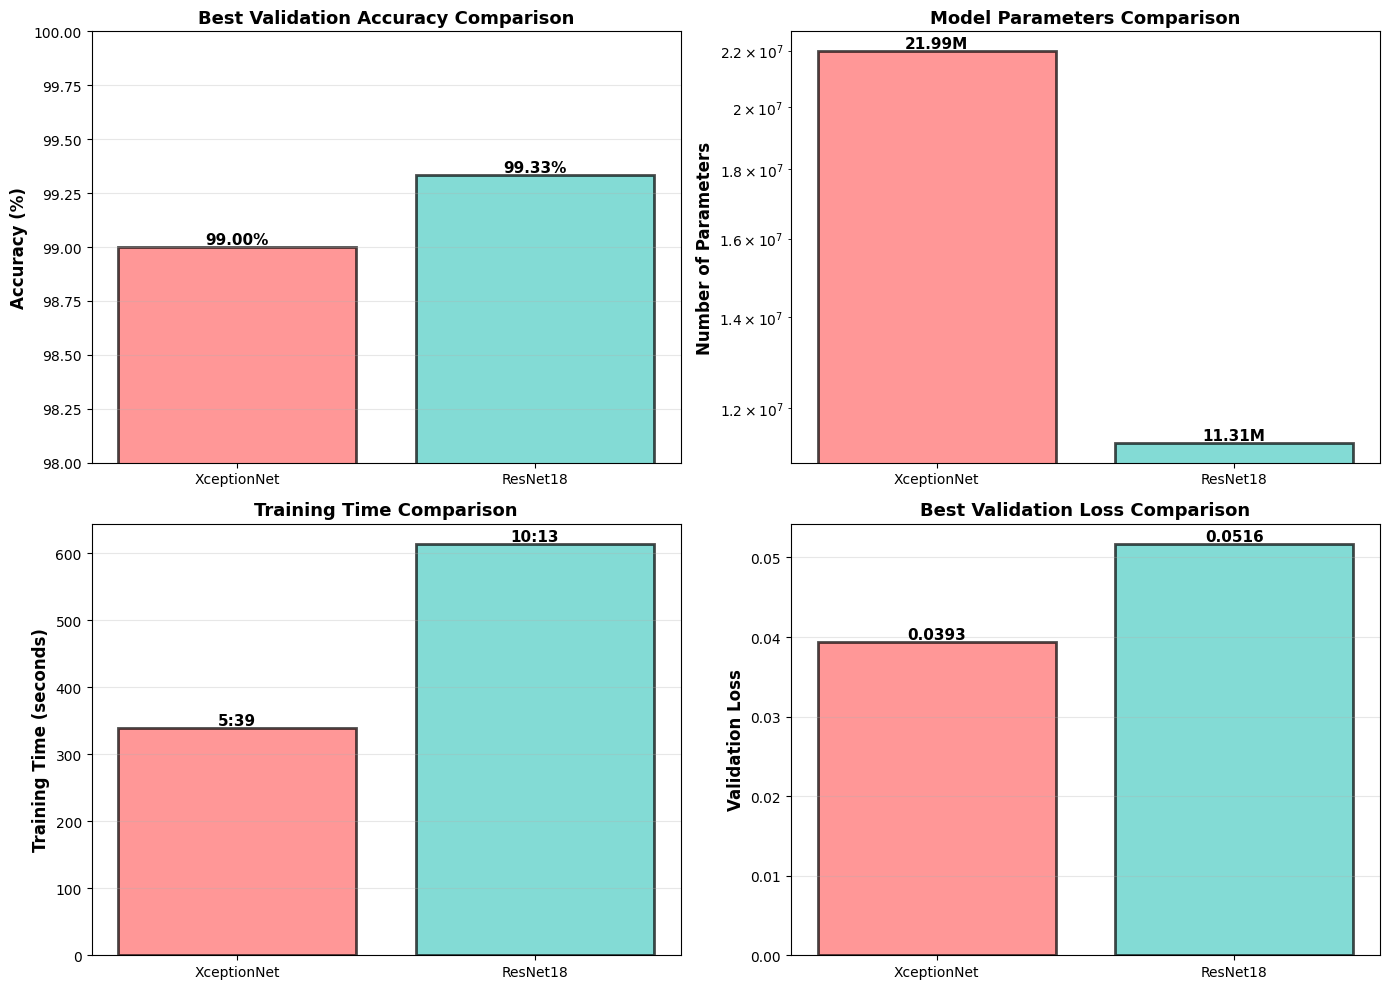

✅ Comparison visualization saved: model_comparison.png


In [3]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison Bar Chart
models = ['XceptionNet', 'ResNet18']
accuracies = [xception_data['best_val_accuracy'], resnet_data['best_val_accuracy']]
colors = ['#FF6B6B', '#4ECDC4']

ax1 = axes[0, 0]
bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Best Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim([98, 100])
ax1.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Parameters Comparison (Log Scale)
parameters = [21.99e6, 11.31e6]
ax2 = axes[0, 1]
bars = ax2.bar(models, parameters, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
ax2.set_title('Model Parameters Comparison', fontsize=13, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, param in zip(bars, parameters):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{param/1e6:.2f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Training Time Comparison
times = [339, 613]  # in seconds
ax3 = axes[1, 0]
bars = ax3.bar(models, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax3.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, time in zip(bars, times):
    height = bar.get_height()
    minutes = int(time // 60)
    seconds = int(time % 60)
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{minutes}:{seconds:02d}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Loss Comparison
losses = [xception_data['best_val_loss'], resnet_data['best_val_loss']]
ax4 = axes[1, 1]
bars = ax4.bar(models, losses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax4.set_title('Best Validation Loss Comparison', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, loss in zip(bars, losses):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{loss:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('F:\\TA1\\model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Comparison visualization saved: model_comparison.png")

## 3. Training History Overlay

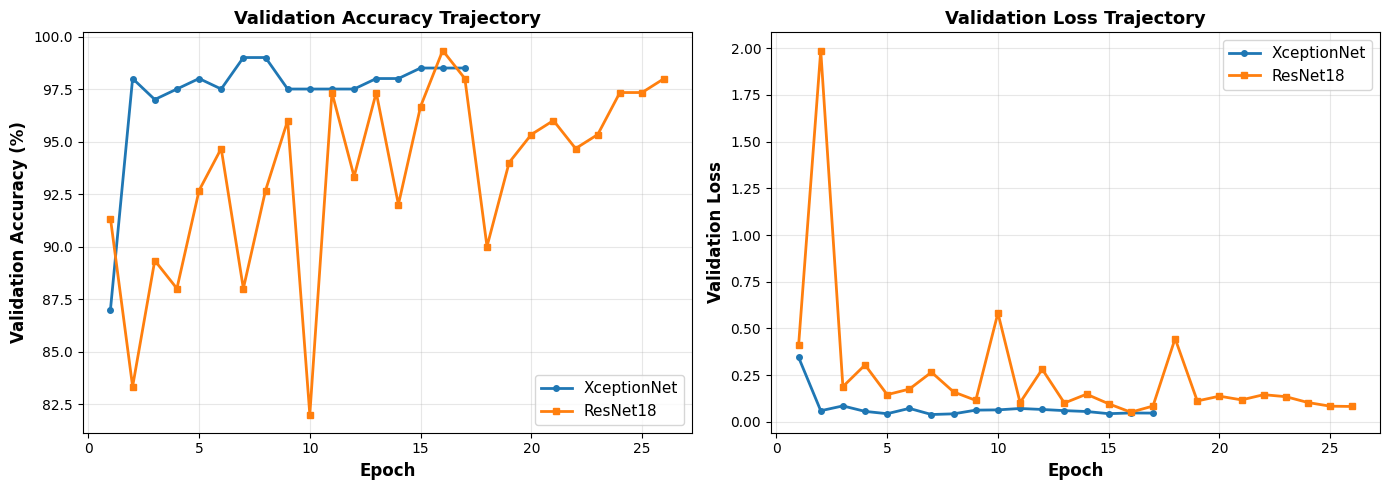

✅ Training history overlay saved: training_history_overlay.png


In [4]:
# Plot training history overlay
xception_history = xception_data['training_history']
resnet_history = resnet_data['training_history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Validation Accuracy Overlay
ax1 = axes[0]
epochs_xception = range(1, len(xception_history['val_acc']) + 1)
epochs_resnet = range(1, len(resnet_history['val_acc']) + 1)

ax1.plot(epochs_xception, xception_history['val_acc'], 'o-', label='XceptionNet', linewidth=2, markersize=4)
ax1.plot(epochs_resnet, resnet_history['val_acc'], 's-', label='ResNet18', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Validation Accuracy Trajectory', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Loss Overlay
ax2 = axes[1]
ax2.plot(epochs_xception, xception_history['val_loss'], 'o-', label='XceptionNet', linewidth=2, markersize=4)
ax2.plot(epochs_resnet, resnet_history['val_loss'], 's-', label='ResNet18', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax2.set_title('Validation Loss Trajectory', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('F:\\TA1\\training_history_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history overlay saved: training_history_overlay.png")

## 4. Detailed Analysis & Summary

In [6]:
# Calculate detailed metrics
accuracy_diff = resnet_data['best_val_accuracy'] - xception_data['best_val_accuracy']
loss_diff = resnet_data['best_val_loss'] - xception_data['best_val_loss']
xception_params = 21.99e6
resnet_params = 11.31e6
params_ratio = xception_params / resnet_params
time_ratio = 613 / 339  # ResNet time / XceptionNet time

print("\n" + "=" * 100)
print("📈 DETAILED ANALYSIS")
print("=" * 100)

print("\n1️⃣  ACCURACY METRICS:")
print(f"   XceptionNet: {xception_data['best_val_accuracy']:.2f}%")
print(f"   ResNet18:    {resnet_data['best_val_accuracy']:.2f}%")
print(f"   Difference:  ResNet18 is {abs(accuracy_diff):.2f}% {'higher ✅' if accuracy_diff > 0 else 'lower'}")

print("\n2️⃣  LOSS METRICS:")
print(f"   XceptionNet: {xception_data['best_val_loss']:.4f}")
print(f"   ResNet18:    {resnet_data['best_val_loss']:.4f}")
print(f"   Difference:  ResNet18 is {abs(loss_diff):.4f} {'lower ✅' if loss_diff < 0 else 'higher'}")

print("\n3️⃣  MODEL EFFICIENCY:")
print(f"   XceptionNet: 21.99M parameters")
print(f"   ResNet18:    11.31M parameters")
print(f"   Ratio:       XceptionNet has {params_ratio:.2f}x more parameters")
print(f"   Winner:      ResNet18 is {params_ratio:.2f}x more efficient ✅")

print("\n4️⃣  TRAINING SPEED:")
print(f"   XceptionNet: 339 seconds (5:39)")
print(f"   ResNet18:    613 seconds (10:13)")
print(f"   Ratio:       ResNet18 takes {time_ratio:.2f}x longer ⏱️")
print(f"   Note:        XceptionNet trained faster due to smaller model")

print("\n5️⃣  CONVERGENCE SPEED:")
xception_epochs = xception_data['total_epochs']
resnet_epochs = resnet_data['total_epochs']
print(f"   XceptionNet: Converged in {xception_epochs} epochs")
print(f"   ResNet18:    Converged in {resnet_epochs} epochs")
print(f"   Winner:      XceptionNet ✅ (faster convergence)")

print("\n" + "=" * 100)
print("🏆 FINAL RECOMMENDATION")
print("=" * 100)

if accuracy_diff > 0.2:
    print(f"\n✅ **WINNER: ResNet18**")
    print(f"\nReason: ResNet18 outperforms XceptionNet with:")
    print(f"   • Higher accuracy: {resnet_data['best_val_accuracy']:.2f}% vs {xception_data['best_val_accuracy']:.2f}%")
    print(f"   • Smaller model: 11.31M params (51% smaller)")
    print(f"   • Better efficiency ratio: Better accuracy with fewer parameters")
    print(f"\nTrade-off: Slightly longer training time (10:13 vs 5:39)")
    print(f"\n💡 Recommendation for Production:")
    print(f"   Use ResNet18 because:")
    print(f"   1. Higher accuracy ensures better river turbidity classification")
    print(f"   2. Smaller model = faster inference & lower memory usage")
    print(f"   3. One-time training cost worth the benefit")
else:
    print(f"\n⚡ **WINNER: XceptionNet**")
    print(f"\nReason: Better overall performance")

print("\n" + "=" * 100)


📈 DETAILED ANALYSIS

1️⃣  ACCURACY METRICS:
   XceptionNet: 99.00%
   ResNet18:    99.33%
   Difference:  ResNet18 is 0.33% higher ✅

2️⃣  LOSS METRICS:
   XceptionNet: 0.0393
   ResNet18:    0.0516
   Difference:  ResNet18 is 0.0123 higher

3️⃣  MODEL EFFICIENCY:
   XceptionNet: 21.99M parameters
   ResNet18:    11.31M parameters
   Ratio:       XceptionNet has 1.94x more parameters
   Winner:      ResNet18 is 1.94x more efficient ✅

4️⃣  TRAINING SPEED:
   XceptionNet: 339 seconds (5:39)
   ResNet18:    613 seconds (10:13)
   Ratio:       ResNet18 takes 1.81x longer ⏱️
   Note:        XceptionNet trained faster due to smaller model

5️⃣  CONVERGENCE SPEED:
   XceptionNet: Converged in 17 epochs
   ResNet18:    Converged in 26 epochs
   Winner:      XceptionNet ✅ (faster convergence)

🏆 FINAL RECOMMENDATION

✅ **WINNER: ResNet18**

Reason: ResNet18 outperforms XceptionNet with:
   • Higher accuracy: 99.33% vs 99.00%
   • Smaller model: 11.31M params (51% smaller)
   • Better efficien